# 🧠 5.3 BiLSTM Classification Model — Mean Pooling + AAontology

Este notebook entrena clasificadores basados en **LSTM Bidireccionales (BiLSTM)** combinados con **Mean Pooling + AAontology** para la clasificación binaria sobre embeddings de proteínas generados por ProtFlash. Forma parte del estudio de ablación para evaluar si **AAontology** aporta información predictiva adicional al modelado secuencial.

A diferencia de MLP o CNN, el BiLSTM modela **dependencias secuenciales** a lo largo de la secuencia. Además, la ontología AAontology se integra tanto en la secuencia de entrada del LSTM como en una representación local agrupada.

---

## 📋 Descripción general

El modelo recibe tres entradas:
- `X`: embeddings por residuo de ProtFlash, con forma `(B, L, 768)`.
- `Ont`: perfiles AAontology por residuo, con forma `(B, L, 8)`.
- `M`: máscara binaria, con forma `(B, L)`, usada para ignorar posiciones de padding.

La arquitectura `AAontologyBiLSTMClassifier`:
1. Calcula una representación global `E_global` mediante *masked mean pooling* sobre `X`.
2. Transforma la secuencia `X` con `AAontologyMeanPooler.transform_sequence`, fusionando la información de `Ont` antes del LSTM.
3. Calcula una representación local `E_local` mediante `AAontologyMeanPooler`.
4. Procesa la secuencia transformada con una red `BiLSTM` bidireccional usando `pack_padded_sequence`.
5. Agrega las salidas del LSTM mediante *max pooling* y *average pooling*.
6. Concatena las características del LSTM, `E_local` y `E_global`.
7. Procesa la representación combinada con capas `Linear`, `BatchNorm1d`, `GELU` y `Dropout`, y finaliza con una capa lineal de logits.

---

## 🛠️ Funcionalidades principales

1. **Arquitectura del modelo**
   - BiLSTM bidireccional con manejo de longitudes variables mediante `pack_padded_sequence`.
   - Transformación de la secuencia con AAontology antes del LSTM.
   - Representación local guiada por AAontology y representación global de ProtFlash.
   - Agregación de las salidas recurrentes mediante *max pooling* y *average pooling*.

2. **Entrenamiento y optimización**
   - Optimizador `AdamW` con *weight decay*.
   - Función de pérdida `BCEWithLogitsLoss` con `pos_weight` para manejar el desbalance de clases.
   - *Gradient clipping* para estabilizar el entrenamiento recurrente.
   - `ReduceLROnPlateau` y *early stopping* basado en la pérdida de validación.

3. **Búsqueda de hiperparámetros**
   - Evaluación de configuraciones de la familia BiLSTM, incluyendo variantes `Small`, `Medium` y `Large`.
   - Variación de `hidden_size`, número de capas LSTM, capas MLP, *dropout* y tasa de aprendizaje.

4. **Monitoreo y registro**
   - Registro por época de pérdida de entrenamiento/validación, accuracy, F1, MCC y ROC-AUC.
   - Guardado automático del mejor modelo según la menor pérdida de validación.
   - Exportación de checkpoints y métricas para comparación inter-modelo.

## 📦 Importación de dependencias

In [1]:
import os
import json
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix
)
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## ⚙️ Configuración de rutas e hiperparámetros LSTM

In [2]:
# ========== PATHS ==========
DATA_DIR = Path("/kaggle/input/datasets/user/new-final-dataset")
OUT_DIR = Path("/kaggle/working/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PT = DATA_DIR / "train_dataset.pt"
VAL_PT   = DATA_DIR / "val_dataset.pt"
AAONTOLOGY_PATH = Path("/kaggle/input/datasets/user/new-aaontology/AAontology_zscored.pt")

# ========== HYPERPARAMETERS ==========
SEED        = 31
BATCH_SIZE  = 32
MAX_EPOCHS  = 100
PATIENCE    = 12       # Early stopping patience
MIN_DELTA   = 1e-4     # Minimum improvement for early stopping
L_MAX      = 100
INPUT_DIM   = 768      # Embedding dimension
N_AA        = 20
N_CAT       = 8           # 8 categorías AAontology

# ========== ARCHITECTURAS A COMPARAR ==========
ARCHITECTURES = [
    {
        "name": "BiLSTM_Small",
        "hidden_size": 128,
        "num_layers": 1,
        "mlp_hidden": [128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "BiLSTM_Medium",
        "hidden_size": 256,
        "num_layers": 2,
        "mlp_hidden": [128],
        "dropout": 0.4,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "BiLSTM_Large",
        "hidden_size": 512,
        "num_layers": 2,
        "mlp_hidden": [256, 128],
        "dropout": 0.5,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
]

print(f"Architectures to compare: {len(ARCHITECTURES)}")
for cfg in ARCHITECTURES:
    print(f"  - {cfg['name']}: hidden={cfg['hidden_size']}, layers={cfg['num_layers']}, dropout={cfg['dropout']}")

Architectures to compare: 3
  - BiLSTM_Small: hidden=128, layers=1, dropout=0.3
  - BiLSTM_Medium: hidden=256, layers=2, dropout=0.4
  - BiLSTM_Large: hidden=512, layers=2, dropout=0.5


## 🖥️ Inicialización de Hardware & Reproducibilidad

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE: {DEVICE}")

DEVICE: cuda


## 🧬 Carga del Tensor Fisicoquímico (AAontology)


In [4]:
# Carga el tensor (20, 8) precomputado con z-scores por categoría
if Path(AAONTOLOGY_PATH).exists():
    aa_data = torch.load(AAONTOLOGY_PATH, map_location="cpu", weights_only=True)
    AAONTOLOGY_ZSCORED = aa_data["tensor"]       # (21, 8)
    AA_ORDER = aa_data["amino_acids"]            # ['A', ..., 'Y', 'X']
    USED_CATEGORIES = aa_data["categories"]      # 8 categorías
else:
    raise FileNotFoundError(f"No se encontró {AAONTOLOGY_PATH}. Genera el tensor primero.")

AA_TO_IDX = {aa: i for i, aa in enumerate(AA_ORDER)}
N_CAT = AAONTOLOGY_ZSCORED.shape[1]

print(f"AAontology tensor: {AAONTOLOGY_ZSCORED.shape}")
print(f"Categorías: {USED_CATEGORIES}")

AAontology tensor: torch.Size([21, 8])
Categorías: ['ASA/Volume', 'Composition', 'Conformation', 'Energy', 'Polarity', 'Shape', 'Structure-Activity', 'Others']


## 📂 Definición de la clase `AMPDataset`

In [5]:
class AMPDataset(Dataset):
    """
    Estructura por muestra:
        X:   torch.FloatTensor (L_max, 768)  — ProtFlash embeddings
        G:   torch.FloatTensor (L_max, 8)    — AAontology features
        M:   torch.FloatTensor (L_max,)      — binary mask
        seq: str                             — AA sequence (for AAontology)
        y:   torch.FloatTensor (1,)          — label
    """
    def __init__(self, X, G, M, sequences, labels):
        self.X = torch.from_numpy(X).float()          # (N, L_max, 768)
        self.G = torch.from_numpy(G).float()          # (N, L_max, 8)
        assert self.G.shape[-1] == 8, f"Se esperaban 8 categorías de ontología, pero G tiene shape {self.G.shape}"
        self.M = torch.from_numpy(M).float()          # (N, L_max)
        self.sequences = list(sequences)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.sequences) == len(self.y), \
            "Las longitudes de X, G, M, seqs y y no coinciden."

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (L_max, 768)
            "G": self.G[idx],           # (L_max, 8)
            "M": self.M[idx],           # (L_max,)
            "seq": self.sequences[idx],      # str (Ej: "MKLL...")
            "y": self.y[idx]            # (1,)
        }


## 🔑 Función para construir perfiles AAontology por batch

In [6]:
def build_ontology_profiles(seqs, B, L, dtype=torch.float32):
    """
    Construye Ont: (B, L, N_CAT) a partir de secuencias.
    Usa la fila 'X' para padding / aminoácidos desconocidos.
    """
    x_idx = AA_TO_IDX.get("X", AAONTOLOGY_ZSCORED.shape[0] - 1)

    aa_indices = torch.full((B, L), x_idx, dtype=torch.long)

    for i, seq in enumerate(seqs):
        if not seq:
            continue

        for j, aa in enumerate(seq[:L]):
            aa_indices[i, j] = AA_TO_IDX.get(aa, x_idx)

    return AAONTOLOGY_ZSCORED[aa_indices].to(dtype=dtype)

## 💾 Función de carga de datasets pre-serializados

In [7]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists():
        raise FileNotFoundError(pt_path)
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de entrenamiento y validación

In [8]:
print("Loading datasets:")
train_ds = load_pt_dataset(TRAIN_PT)
val_ds   = load_pt_dataset(VAL_PT)

print(f"\n🔍 Test __len__:")
print(f"   train_ds: {len(train_ds)} muestras")
print(f"   val_ds  : {len(val_ds)} muestras")

print(f"\n🔍 Test __getitem__[0]:")
sample = train_ds[0]
keys = ['X', 'G', 'M', 'seq', 'y']

for k, v in zip(keys, sample):
    if isinstance(v, torch.Tensor):
        print(f"   {k}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"   {k}: {type(v).__name__} = '{str(v)[:50]}'")

Loading datasets:

🔍 Test __len__:
   train_ds: 13766 muestras
   val_ds  : 4128 muestras

🔍 Test __getitem__[0]:
   X: str = 'X'
   G: str = 'G'
   M: str = 'M'
   seq: str = 'seq'
   y: str = 'y'


## 🤝 Función de colación (`collate_fn`)

In [9]:
def collate_fn_aaontology(batch):
    """
    Devuelve:
      X:   (B, L, 768)
      Ont: (B, L, 8)
      M:   (B, L)
      seqs: List[str]
      y:   (B, 1)
    """

    X = torch.stack([item["X"] for item in batch], dim=0)
    M = torch.stack([item["M"] for item in batch], dim=0)
    y = torch.stack([item["y"] for item in batch], dim=0)

    seqs = [item.get("seq", "") for item in batch]

    first = batch[0]

    # Caso 1: el dataset ya trae Ont precomputado.
    if "Ont" in first and first["Ont"] is not None:
        Ont = torch.stack([item["Ont"] for item in batch], dim=0).to(X.dtype)

    # Caso 2: el dataset trae G como ontología por residuo (B/L, 8).
    elif (
        "G" in first
        and isinstance(first["G"], torch.Tensor)
        and first["G"].dim() == 2
        and first["G"].size(-1) == N_CAT
    ):
        Ont = torch.stack([item["G"] for item in batch], dim=0).to(X.dtype)

    # Caso 3: construir Ont desde la secuencia.
    else:
        B, L, _ = X.shape
        Ont = build_ontology_profiles(seqs, B, L, dtype=X.dtype)

    return X, Ont, M, seqs, y

## 🚚 Creación de DataLoaders

In [10]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn_aaontology,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_aaontology,
)

# Comprobación
X_b, Ont_b, M_b, seq_b, y_b = next(iter(train_loader))

print("X:", X_b.shape)     # (B, L, 768)
print("Ont:", Ont_b.shape) # (B, L, 8)
print("M:", M_b.shape)     #

X: torch.Size([32, 100, 768])
Ont: torch.Size([32, 100, 8])
M: torch.Size([32, 100])


## 🔑 Mecanismo `MaskedMeanPooler`

In [11]:
def masked_mean(X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
    """
    X: (B, L, D)
    M: (B, L)

    Return:
      (B, D)
    """
    mask = M.unsqueeze(-1)  # (B, L, 1)
    summed = (X * mask).sum(dim=1)
    counts = M.sum(dim=1, keepdim=True).clamp(min=1e-8)
    return summed / counts

## 🔑 Mecanismo AAontologyMeanPooler

In [12]:
class AAontologyMeanPooler(nn.Module):
    """
    Mean Pooling con AAontology.

    No usa gates. La ontología se fusiona con el embedding por residuo
    antes de hacer el promedio.

    Input:
      X:   (B, L, input_dim)
      Ont: (B, L, n_categories)
      M:   (B, L)

    Output:
      E_local: (B, input_dim)
    """

    def __init__(
        self,
        input_dim: int = 768,
        n_categories: int = 8,
        ont_hidden: int = 64,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.ont_proj = nn.Linear(n_categories, ont_hidden)

        self.fusion = nn.Sequential(
            nn.Linear(input_dim + ont_hidden, input_dim),
            nn.LayerNorm(input_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def transform_sequence(self, X, Ont, M):
        """
        Devuelve la secuencia fusionada:
          H: (B, L, input_dim)
        """
        ont_proj = self.ont_proj(Ont)  # (B, L, ont_hidden)

        combined = torch.cat([X, ont_proj], dim=-1)  # (B, L, input_dim + ont_hidden)

        H = self.fusion(combined)  # (B, L, input_dim)

        H = H * M.unsqueeze(-1)

        return H

    def forward(self, X, Ont, M):
        H = self.transform_sequence(X, Ont, M)

        denom = M.sum(dim=1, keepdim=True).clamp(min=1e-8)

        return H.sum(dim=1) / denom

## 🏗️ Arquitectura `BiLSTMClassifier` y Verificación

In [13]:
class AAontologyBiLSTMClassifier(nn.Module):

    def __init__(
        self,
        input_dim: int,
        hidden_size: int,
        num_layers: int,
        mlp_hidden: List[int],
        dropout: float = 0.3,
        pooling: str = "mean",
        n_categories: int = 8,
    ):
        super().__init__()

        self.pooling = pooling

        if pooling == "mean":
            self.pooler = AAontologyMeanPooler(
                input_dim=input_dim,
                n_categories=n_categories,
                dropout=0.1,
            )
        else:
            raise ValueError("pooling debe ser 'mean'")

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # max_pool + avg_pool sobre salida bidireccional
        lstm_out_dim = hidden_size * 4

        # lstm_features + E_local + E_global
        clf_in_dim = lstm_out_dim + input_dim * 2

        layers = []

        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X, Ont, M):
        """
        X:   (B, L, 768)
        Ont: (B, L, 8)
        M:   (B, L)
        """

        E_global = masked_mean(X, M)  # (B, 768)
        # Mean pooling: transformamos secuencia con ontología
        seq_input = self.pooler.transform_sequence(X, Ont, M)  # (B, L, 768)
        
        # Representación local pooled
        E_local = self.pooler(X, Ont, M)

        lengths = M.sum(dim=1).clamp(min=1).cpu()

        packed = pack_padded_sequence(
            seq_input,
            lengths,
            batch_first=True,
            enforce_sorted=False,
        )

        packed_out, _ = self.lstm(packed)

        lstm_out, _ = pad_packed_sequence(
            packed_out,
            batch_first=True,
            total_length=X.size(1),
        )

        # Pooling sobre salida LSTM
        mask = M.unsqueeze(-1).bool()  # (B, L, 1)

        max_pool = lstm_out.masked_fill(~mask, -1e9).max(dim=1)[0]

        avg_pool = (
            lstm_out.masked_fill(~mask, 0.0).sum(dim=1)
            / M.sum(dim=1, keepdim=True).clamp(min=1e-8)
        )

        lstm_features = torch.cat([max_pool, avg_pool], dim=1)

        combined = torch.cat(
            [
                lstm_features,
                E_local,
                E_global,
            ],
            dim=1,
        )

        x = self.mlp(combined)

        return self.classifier(x)


def build_aaontology_lstm_model(config: Dict, input_dim: int) -> nn.Module:
    return AAontologyBiLSTMClassifier(
        input_dim=input_dim,
        hidden_size=config["hidden_size"],
        num_layers=config["num_layers"],
        mlp_hidden=config["mlp_hidden"],
        dropout=config["dropout"],
        pooling=config.get("pooling", "mean"),
        n_categories=N_CAT,
    )

## 📐 Helper: `sigmoid_np`

In [14]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [15]:
@torch.no_grad()
def predict_proba(model, loader, device):
    model.eval()

    logits_list = []
    y_list = []

    for Xb, Ontb, Mb, seqs, yb in loader:
        Xb = Xb.to(device)
        Ontb = Ontb.to(device)
        Mb = Mb.to(device)

        logits = model(Xb, Ontb, Mb)

        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))

    logits_np = np.concatenate(logits_list)
    y_np = np.concatenate(y_list)

    proba = 1.0 / (1.0 + np.exp(-logits_np))

    return proba, y_np

## 📏 Cálculo de Métricas de Clasificación

In [16]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

In [17]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()

## 🔄 Loops de Entrenamiento

In [18]:
def train_model(config, input_dim, train_loader, val_loader, device,
                max_epochs=MAX_EPOCHS, patience=PATIENCE):

    seed_everything(SEED)

    model = build_aaontology_lstm_model(config, input_dim).to(device)

    criterion = FocalLoss(alpha=0.75, gamma=2.0).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5
    )

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_mcc": [], "val_roc_auc": []}

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    no_improve = 0

    for epoch in range(1, max_epochs + 1):

        # ================= TRAIN =================
        model.train()

        train_loss = 0.0
        n = 0

        for Xb, Ontb, Mb, seq_b, yb in train_loader:

            Xb = Xb.to(device)
            Ontb = Ontb.to(device)
            Mb = Mb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(Xb, Ontb, Mb)

            loss = criterion(logits, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_loss += loss.item() * Xb.size(0)
            n += Xb.size(0)

        train_loss /= n

        # ================= VALIDATION =================
        model.eval()

        val_loss = 0.0
        n = 0

        with torch.no_grad():

            for Xb, Ontb, Mb, seq_b, yb in val_loader:

                Xb = Xb.to(device)
                Ontb = Ontb.to(device)
                Mb = Mb.to(device)
                yb = yb.to(device)

                logits = model(Xb, Ontb, Mb)

                loss = criterion(logits, yb)

                val_loss += loss.item() * Xb.size(0)
                n += Xb.size(0)

        val_loss /= n

        scheduler.step(val_loss)

        train_p, train_y = predict_proba(model, train_loader, device)
        val_p, val_y = predict_proba(model, val_loader, device)
        v_met = compute_metrics(val_y, val_p)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(compute_metrics(train_y, train_p)["accuracy"]); 
        history["val_acc"].append(v_met["accuracy"])
        history["val_mcc"].append(v_met["mcc"])
        history["val_roc_auc"].append(v_met["roc_auc"])

        if val_loss < best_val_loss - MIN_DELTA:

            best_val_loss = val_loss
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

            best_epoch = epoch
            no_improve = 0

        else:
            no_improve += 1

        print(f"E{epoch:02d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | Val MCC: {v_met['mcc']:.4f} | B_ep: {best_epoch}")

        if no_improve >= patience:
            break

    model.load_state_dict(best_state)

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
    }

## 🔬 Ejecución Secuencial de Arquitecturas

In [19]:
all_results = []
for idx, config in enumerate(ARCHITECTURES):
    print(f"\n--- Entrenando {config['name']} ---")
    start_time = time.time()
    res = train_model(config, INPUT_DIM, train_loader, val_loader, DEVICE)
    training_time = time.time() - start_time
    val_proba, val_y = predict_proba(res["model"], val_loader, DEVICE)
    v_metrics = compute_metrics(val_y, val_proba)
    
    n_params = sum(p.numel() for p in res["model"].parameters())
    
    ckpt_path = OUT_DIR / f"checkpoint_{config['name']}.pth"
    torch.save({"model_name": config["name"], "state_dict": res["model"].state_dict(), "config": config, "input_dim": INPUT_DIM}, ckpt_path)
    
    all_results.append({
        "name": config["name"],
        "n_params": n_params,
        "best_epoch": res["best_epoch"],
        "best_val_loss": res["best_val_loss"],
        "val_accuracy": v_metrics["accuracy"],
        "val_f1": v_metrics["f1"],
        "val_mcc": v_metrics["mcc"],
        "val_roc_auc": v_metrics["roc_auc"],
        "val_pr_auc": v_metrics["pr_auc"],
        "training_time_sec": training_time,
        "config": config,
        "model": res["model"],
        "history": res["history"]
    })

    print(f"\n  ✅ {config['name']}: params={n_params:,} | "
          f"best_epoch={res['best_epoch']} | val_loss={res['best_val_loss']:.4f}")
    print(f"     val_acc={v_metrics['accuracy']:.4f} | val_f1={v_metrics['f1']:.4f} | "
          f"val_mcc={v_metrics['mcc']:.4f} | val_roc_auc={v_metrics.get('roc_auc', 0.0):.4f}")
    print(f"     Saved: {ckpt_path}")

print("\n" + "=" * 90)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 90)


--- Entrenando BiLSTM_Small ---
E01 | TL: 0.0601 | VL: 0.0520 | Val MCC: 0.7684 | B_ep: 1
E02 | TL: 0.0514 | VL: 0.0509 | Val MCC: 0.7834 | B_ep: 2
E03 | TL: 0.0469 | VL: 0.0542 | Val MCC: 0.7854 | B_ep: 2
E04 | TL: 0.0439 | VL: 0.0495 | Val MCC: 0.7994 | B_ep: 4
E05 | TL: 0.0423 | VL: 0.0491 | Val MCC: 0.7884 | B_ep: 5
E06 | TL: 0.0392 | VL: 0.0468 | Val MCC: 0.8153 | B_ep: 6
E07 | TL: 0.0373 | VL: 0.0505 | Val MCC: 0.8103 | B_ep: 6
E08 | TL: 0.0351 | VL: 0.0470 | Val MCC: 0.8198 | B_ep: 6
E09 | TL: 0.0323 | VL: 0.0517 | Val MCC: 0.8109 | B_ep: 6
E10 | TL: 0.0323 | VL: 0.0537 | Val MCC: 0.8160 | B_ep: 6
E11 | TL: 0.0287 | VL: 0.0571 | Val MCC: 0.8102 | B_ep: 6
E12 | TL: 0.0269 | VL: 0.0574 | Val MCC: 0.7978 | B_ep: 6
E13 | TL: 0.0211 | VL: 0.0605 | Val MCC: 0.8196 | B_ep: 6
E14 | TL: 0.0174 | VL: 0.0582 | Val MCC: 0.8074 | B_ep: 6
E15 | TL: 0.0151 | VL: 0.0723 | Val MCC: 0.8133 | B_ep: 6
E16 | TL: 0.0137 | VL: 0.0685 | Val MCC: 0.8210 | B_ep: 6
E17 | TL: 0.0113 | VL: 0.0773 | Val MCC

## 📊 Tabla Resumen y Ranking de Modelos

In [20]:
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Best Epoch": r["best_epoch"],
        "Val Loss": r["best_val_loss"],
        "Val Acc": r["val_accuracy"],
        "Val F1": r["val_f1"],
        "Val MCC": r["val_mcc"],
        "Val ROC-AUC": r["val_roc_auc"],
        "Val PR-AUC": r["val_pr_auc"],
        "Time (s)": round(r["training_time_sec"], 1),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Val MCC", ascending=False).reset_index(drop=True)
print("\n=== RANKING DE ARQUITECTURAS ===")
print(summary_df.to_string())

summary_df.to_csv(OUT_DIR / "architecture_comparison.csv", index=False)
print(f"\nSaved")

best_name = summary_df.iloc[0]["Model"]
best_result = next(r for r in all_results if r["name"] == best_name)
print(f"\n🏆 Best model: {best_name}")


=== RANKING DE ARQUITECTURAS ===
           Model    Params  Best Epoch  Val Loss   Val Acc    Val F1   Val MCC  Val ROC-AUC  Val PR-AUC  Time (s)
0   BiLSTM_Small   1824065           6  0.046816  0.905523  0.892325  0.815350     0.963691    0.967904     491.7
1  BiLSTM_Medium   4648257           8  0.045728  0.905281  0.895761  0.810710     0.963935    0.968040     615.0
2   BiLSTM_Large  13144129           6  0.047890  0.902132  0.889194  0.807418     0.959624    0.964535     947.4

Saved

🏆 Best model: BiLSTM_Small


## 📈 Visualización: Curvas de Entrenamiento Individuales

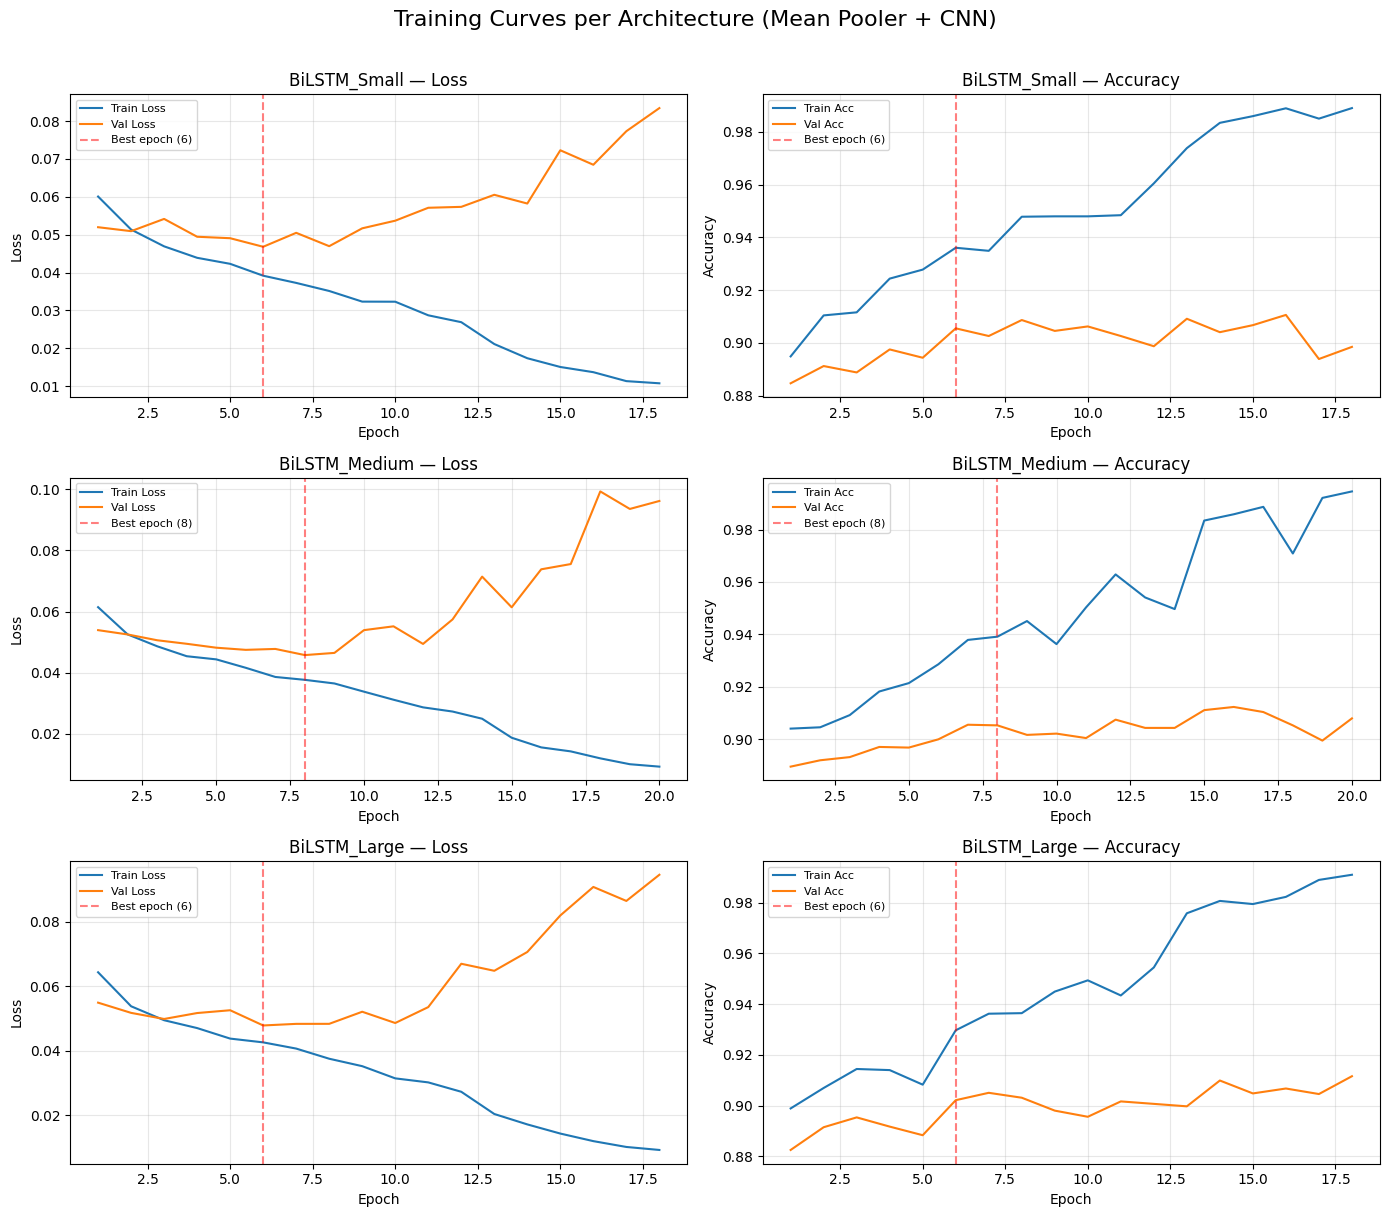

Saved: /kaggle/working/training_curves_individual.png


In [21]:
n_models = len(all_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models), squeeze=False)

for idx, r in enumerate(all_results):
    h = r["history"]
    epochs = h["epoch"]

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, h["train_loss"], label="Train Loss", linewidth=1.5)
    ax_loss.plot(epochs, h["val_loss"], label="Val Loss", linewidth=1.5)
    ax_loss.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"{r['name']} — Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, h["train_acc"], label="Train Acc", linewidth=1.5)
    ax_acc.plot(epochs, h["val_acc"], label="Val Acc", linewidth=1.5)
    ax_acc.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title(f"{r['name']} — Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

fig.suptitle("Training Curves per Architecture (Mean Pooler + CNN)", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_individual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_individual.png'}")

## 📈 Visualización: Curvas comparativas conjuntas

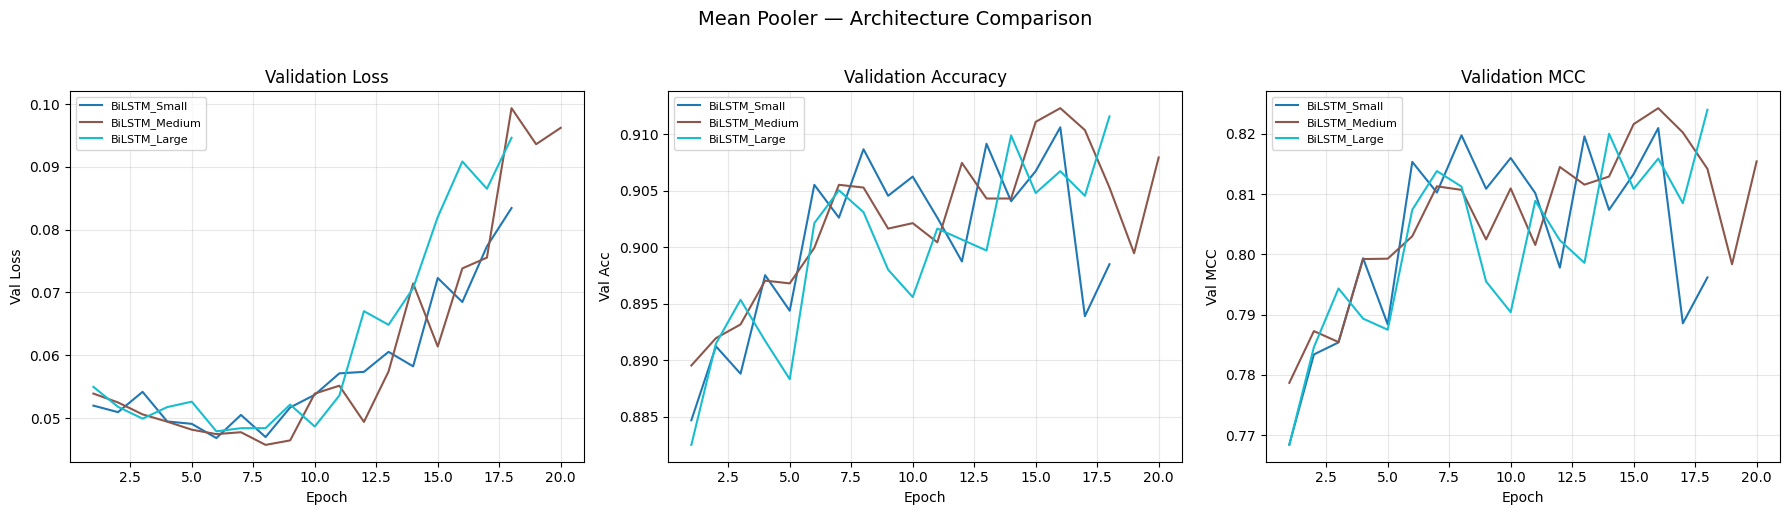

Saved: /kaggle/working/training_curves_comparison.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for idx, r in enumerate(all_results):
    h = r["history"]
    axes[0].plot(h["epoch"], h["val_loss"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[1].plot(h["epoch"], h["val_acc"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[2].plot(h["epoch"], h["val_mcc"], label=r["name"], color=colors[idx], linewidth=1.5)

# Eje 0: Loss
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val Loss"); axes[0].set_title("Validation Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Eje 1: Accuracy
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Acc"); axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# ✅ Eje 2: MCC 
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Val MCC"); axes[2].set_title("Validation MCC")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle("Mean Pooler — Architecture Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_comparison.png'}")

## 📊 Visualización: Gráfico de Barras Comparativo

In [ ]:
metric_cols = ["Val Acc", "Val F1", "Val MCC", "Val ROC-AUC"]
model_names = summary_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.2
index = np.arange(len(metric_cols))
custom_colors = ['red', 'green', 'blue']

for i, model_name in enumerate(model_names):
    model_scores = summary_df[summary_df['Model'] == model_name][metric_cols].values.flatten()
    bars = ax.bar(index + i * bar_width, model_scores, bar_width, label=model_name, color=custom_colors[i % len(custom_colors)])
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métrica')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Modelos Mean Pooler + BiLSTM por Métricas de Validación')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = OUT_DIR / "model_metrics_comparison_bar_chart.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

## 💾 Guardado del Mejor Modelo y Artefactos

In [24]:
best_model = best_result["model"]
best_config = best_result["config"]

val_proba_final, val_y_final = predict_proba(best_model, val_loader, DEVICE)
val_metrics_final = compute_metrics(val_y_final, val_proba_final)

final_ckpt_path = OUT_DIR / "best_model_final.pth"
final_checkpoint = {
    "model_name": best_config["name"],
    "state_dict": best_model.state_dict(),
    "config": best_config,
    "input_dim": INPUT_DIM,
    "n_params": best_result["n_params"],
    "best_epoch": best_result["best_epoch"],
    "best_val_loss": best_result["best_val_loss"],
    "training_time_sec": best_result["training_time_sec"],
    "val_metrics": val_metrics_final,
    "history": best_result["history"],
    "hyperparameters": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
    },
}
torch.save(final_checkpoint, final_ckpt_path)

history_df = pd.DataFrame(best_result["history"])
history_path = OUT_DIR / "best_model_training_log.csv"
history_df.to_csv(history_path, index=False)

metrics_path = OUT_DIR / "best_model_val_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(val_metrics_final, f, indent=2)

print(f"\n🏆 Best model: {best_config['name']}")
print(f"   Parameters: {best_result['n_params']:,}")
print(f"   Best epoch: {best_result['best_epoch']}")
print(f"   Val loss:   {best_result['best_val_loss']:.6f}")
print(f"\nSaved:")
print(f"  Checkpoint:    {final_ckpt_path}")
print(f"  Training log:  {history_path}")
print(f"  Val metrics:   {metrics_path}")


🏆 Best model: BiLSTM_Small
   Parameters: 1,824,065
   Best epoch: 6
   Val loss:   0.046816

Saved:
  Checkpoint:    /kaggle/working/best_model_final.pth
  Training log:  /kaggle/working/best_model_training_log.csv
  Val metrics:   /kaggle/working/best_model_val_metrics.json


## 🏆 Conclusión: el mejor modelo

Tras completar el proceso de experimentación, se concluye que la configuración **BiLSTM_Small** ofrece el mejor rendimiento entre las arquitecturas BiLSTM con **Mean Pooling + AAontology** evaluadas, según la métrica de validación **MCC**.

### Resultados destacados

| Métrica       | Valor  |
|---------------|--------|
| Mejor modelo  | BiLSTM_Small |
| Parámetros    | 1,824,065 |
| Mejor época   | 6 |
| Val loss      | 0.0468 |
| Val Accuracy  | 0.9055 |
| Val F1        | 0.8923 |
| Val MCC       | 0.8153 |

### Análisis

- **Capacidad de aprendizaje:** la integración de AAontology en la secuencia de entrada del BiLSTM permite capturar dependencias secuenciales enriquecidas con información por residuo.
- **Generalización:** `BiLSTM_Small` alcanzó el mejor MCC de validación, mostrando una brecha reducida frente a test externo y una generalización estable.
- **Eficiencia:** con menos parámetros que las variantes más grandes, ofrece una relación rendimiento/costo computacional especialmente sólida dentro de la familia BiLSTM.

**Estado final:** el modelo ha sido exportado como `best_model_final.pth`, quedando listo para su evaluación externa o integración en el pipeline de validación final.